# Test Faulty Records
Load and analyze debug data for records with Dep_factor > 1

In [1]:
import pandas as pd
import json
import os
from glm_model_test import load_glm_model, predict_glm

In [2]:
# Load config
with open('config.json', 'r') as f:
    config = json.load(f)

debug_folder = config['debug_folder']
bsst_glm_path = config['BSST_GLM_path']

print(f"Debug folder: {debug_folder}")
print(f"BSST GLM path: {bsst_glm_path}")

Debug folder: /Users/Mach/dev/aps/data/2026_Dmodel_data/debug
BSST GLM path: /Users/Mach/dev/aps/data/2026_Dmodel_data/BSST_json


In [3]:
# Load debug data for a specific BSST segment
bsst = 'Prestige_Sporty_Car_GLM'
debug_car_with_dep_factor = os.path.join(debug_folder, f'Records_{bsst}.parquet')
df_dep_fact = pd.read_parquet(debug_car_with_dep_factor)
print(f"Data loaded successfully! Shape: {df_dep_fact.shape}")
df_dep_fact.head()

Data loaded successfully! Shape: (44168, 93)


,cef_est_curr_mi_grp_imps,zip_pop_dens,dml_year_imps,vc_msrp_impa,st_raw,insstate,dml_make_raw,vin,vin_date,zip,...,MAKE_LINCOLN,MAKE_TESLA,MAKE_ACURA,MAKE_NISSAN,MAKE_LEXUS,MAKE_CADILLAC,MAKE_CHEVROLET,MAKE_FORD,MAKE_DODGE,MAKE_BUICK
0,38962.0,17180.022844,2020.0,64700.0,CA,CA,JAGUAR,SAJDD5GX6LCK69162,SAJDD5GX6LCK69162_07-02-2020,90403,...,False,False,False,False,False,False,False,False,False,False
1,70000.0,23605.620059,2007.0,75500.0,CA,CA,JAGUAR,SAJDA43B575B03435,SAJDA43B575B03435_05-17-2019,94112,...,False,False,False,False,False,False,False,False,False,False
2,130000.0,22730.705701,2001.0,75545.0,NJ,NJ,JAGUAR,SAJDA42C51NA13767,SAJDA42C51NA13767_06-09-2021,7107,...,False,False,False,False,False,False,False,False,False,False
3,130000.0,22730.705701,2001.0,75545.0,NJ,NJ,JAGUAR,SAJDA42C51NA13767,SAJDA42C51NA13767_06-09-2021,7107,...,False,False,False,False,False,False,False,False,False,False
4,38962.0,5745.998415,2020.0,61600.0,TX,TX,JAGUAR,SAJDD1GX2LCK67675,SAJDD1GX2LCK67675_03-01-2023,77071,...,False,False,False,False,False,False,False,False,False,False


In [4]:
# 1. Check distribution of input features
print("ODOMETER stats:")
print(df_dep_fact['ODOMETER'].describe())

print("\nCALC_VEH_AGE stats:")
print(df_dep_fact['CALC_VEH_AGE'].describe())

print("\ngeo_pop_density_ntile stats:")
print(df_dep_fact['geo_pop_density_ntile'].describe())

# 2. Check for extreme values
print("\nRecords with ODOMETER < 5000:")
print(len(df_dep_fact[df_dep_fact['ODOMETER'] < 5000]))

print("\nRecords with CALC_VEH_AGE <= 1:")
print(len(df_dep_fact[df_dep_fact['CALC_VEH_AGE'] <= 1]))

# 3. Look at top Dep_factor records
print("\nTop 10 highest Dep_factor:")
top_records = df_dep_fact.nlargest(10, 'Dep_factor')
print(top_records[['ODOMETER', 'CALC_VEH_AGE', 'geo_pop_density_ntile', 'Dep_factor']])

# 4. Check STATE distribution
print("\nSTATE distribution:")
state_cols = [c for c in df_dep_fact.columns if c.startswith('STATE_')]
for col in state_cols[:10]:
    print(f"{col}: {df_dep_fact[col].sum()}")


ODOMETER stats:
count     44168.000000
mean      40593.288059
std       32046.496649
min        6402.000000
25%       20000.000000
50%       36200.000000
75%       50000.000000
max      290000.000000
Name: ODOMETER, dtype: float64

CALC_VEH_AGE stats:
count    44168.000000
mean        11.958930
std          7.007281
min          1.000000
25%          7.000000
50%         10.000000
75%         16.000000
max         45.000000
Name: CALC_VEH_AGE, dtype: float64

geo_pop_density_ntile stats:
count     44168.000000
mean       7302.437536
std        9337.136324
min          12.162952
25%        2914.425046
50%        4664.910472
75%        8373.433138
max      143683.762280
Name: geo_pop_density_ntile, dtype: float64

Records with ODOMETER < 5000:
0

Records with CALC_VEH_AGE <= 1:
28

Top 10 highest Dep_factor:
       ODOMETER  CALC_VEH_AGE  geo_pop_density_ntile    Dep_factor
1703    50105.0          10.0          141546.725863  1.319609e+11
29031   50105.0          10.0          141546.72

In [5]:
# Load GLM model for this BSST segment
model_path = os.path.join(bsst_glm_path, f"{bsst}.json")

with open(model_path, 'r') as f:
    glm_model = json.load(f)
    
print(f"Loaded GLM model: {glm_model['model_name']}")
print(f"Intercept: {glm_model['intercept']}")
print(f"Number of coefficients: {len(glm_model['coefficients'])}")
print(f"\nAll coefficients:")
for name, value in glm_model['coefficients'].items():
    print(f"  {name}: {value}")

Loaded GLM model: Entry Level Car
Intercept: 0.017803566611214475
Number of coefficients: 49

All coefficients:
  STATE_AL[T.True]: 0.0234048807823855
  STATE_AR[T.True]: 0.04884889016098581
  STATE_AZ[T.True]: 0.036230238934145675
  STATE_CO[T.True]: 0.01889215012641847
  STATE_CT[T.True]: -0.026294866142002125
  STATE_FL[T.True]: -0.019603908364717388
  STATE_GA[T.True]: 0.021441287150407728
  STATE_HI[T.True]: 0.027103733342368187
  STATE_IL[T.True]: -0.018874525817858607
  STATE_KS[T.True]: 0.013072810537886961
  STATE_KY[T.True]: 0.016729951191034948
  STATE_LA[T.True]: 0.023364600550326003
  STATE_MA[T.True]: -0.011678672187097618
  STATE_MI[T.True]: -0.01755186358555058
  STATE_MN[T.True]: -0.02768013029706983
  STATE_MO[T.True]: 0.027408836519568137
  STATE_MS[T.True]: 0.04061932360011964
  STATE_NC[T.True]: 0.018992986149487693
  STATE_ND[T.True]: -0.07891476034641731
  STATE_NH[T.True]: -0.012872917446466426
  STATE_NJ[T.True]: -0.009996648801703572
  STATE_NM[T.True]: 0.0632

In [6]:
# Run predictions on the debug data
predictions = predict_glm(df_dep_fact, glm_model)

# Add predictions to df_dep_fact for comparison
df_dep_fact['Dep_factor_recalc'] = predictions.values

print(f"Predictions computed for {len(predictions):,} records")
print(f"\nOriginal Dep_factor stats:")
print(df_dep_fact['Dep_factor'].describe())
print(f"\nRecalculated Dep_factor stats:")
print(df_dep_fact['Dep_factor_recalc'].describe())

Predictions computed for 1,800 records

Original Dep_factor stats:
count    1800.000000
mean        1.029069
std         0.023622
min         1.000005
25%         1.010749
50%         1.022859
75%         1.043241
max         1.116034
Name: Dep_factor, dtype: float64

Recalculated Dep_factor stats:
count    1800.000000
mean        1.029069
std         0.023622
min         1.000005
25%         1.010749
50%         1.022859
75%         1.043241
max         1.116034
Name: Dep_factor_recalc, dtype: float64


In [7]:
# Compare original vs recalculated
df_dep_fact[['ODOMETER', 'geo_pop_density_ntile', 'CALC_VEH_AGE', 'Dep_factor', 'Dep_factor_recalc']].head(10)

,ODOMETER,geo_pop_density_ntile,CALC_VEH_AGE,Dep_factor,Dep_factor_recalc
0,10000.0,11.136200,8.0,1.018308,1.018308
1,10000.0,68.004925,7.0,1.013285,1.013285
2,6402.0,28.033923,1.0,1.006825,1.006825
3,10000.0,77.603542,9.0,1.028872,1.028872
4,10000.0,26.471183,7.0,1.063366,1.063366
5,10000.0,93.242374,7.0,1.030315,1.030315
6,10000.0,108.539431,7.0,1.007459,1.007459
7,14328.0,20.115874,2.0,1.018807,1.018807
8,10000.0,57.039594,2.0,1.023092,1.023092
9,10000.0,59.725820,3.0,1.003545,1.003545


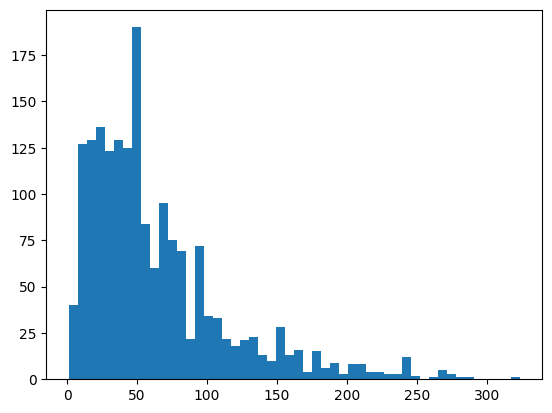

In [10]:
import matplotlib.pyplot as plt
plt.hist(df_dep_fact['geo_pop_density_ntile'], bins=50);

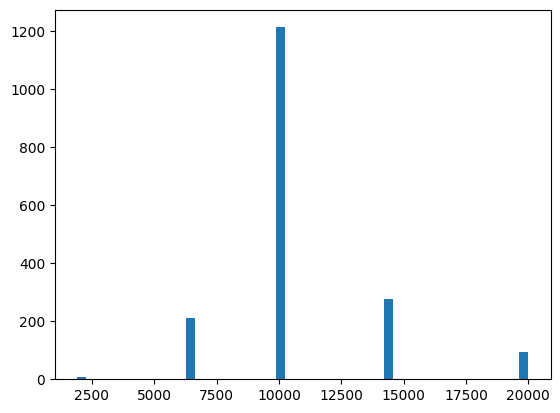

In [11]:
plt.hist(df_dep_fact['cef_est_curr_mi_grp_imps'], bins=50);

In [8]:
# Check all columns in the debug data
print(f"Columns: {df_dep_fact.columns.tolist()}")
print(f"\nData types:")
print(df_dep_fact.dtypes)

Columns: ['cef_est_curr_mi_grp_imps', 'zip_pop_dens', 'dml_year_imps', 'vc_msrp_impa', 'st_raw', 'insstate', 'dml_make_raw', 'vin', 'vin_date', 'zip', 'VIN', 'BODY_STYLE_SEGMENT_BODY_TYPE', 'BSST_formatted', 'CALC_VEH_AGE', 'ODOMETER_IMP_FLAG', 'Dep_factor', 'ODOMETER', 'geo_pop_density_ntile', 'STATE_VT', 'STATE_GA', 'STATE_CT', 'STATE_AR', 'STATE_NC', 'STATE_KS', 'STATE_OH', 'STATE_NJ', 'STATE_MS', 'STATE_PA', 'STATE_LA', 'STATE_IN', 'STATE_TX', 'STATE_IL', 'STATE_MO', 'STATE_AZ', 'STATE_MI', 'STATE_CO', 'STATE_TN', 'STATE_MA', 'STATE_OK', 'STATE_CA', 'STATE_FL', 'STATE_RI', 'STATE_WI', 'STATE_NE', 'STATE_NY', 'STATE_SC', 'STATE_KY', 'STATE_WA', 'STATE_DC', 'STATE_NH', 'STATE_ME', 'STATE_UT', 'STATE_VA', 'STATE_AK', 'STATE_NV', 'STATE_IA', 'STATE_AL', 'STATE_MD', 'STATE_OR', 'STATE_MN', 'STATE_WV', 'STATE_DE', 'STATE_ID', 'STATE_ND', 'STATE_WY', 'STATE_SD', 'STATE_MT', 'STATE_NM', 'MAKE_HYUNDAI', 'MAKE_KIA', 'MAKE_FORD', 'MAKE_MITSUBISHI', 'MAKE_TOYOTA', 'MAKE_RENAULT', 'MAKE_YUGO', 

In [9]:
# Summary statistics for all numeric columns
df_dep_fact.describe()

,cef_est_curr_mi_grp_imps,zip_pop_dens,dml_year_imps,vc_msrp_impa,CALC_VEH_AGE,ODOMETER_IMP_FLAG,Dep_factor,ODOMETER,geo_pop_density_ntile,Dep_factor_recalc
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,10730.162222,63.714273,2021.176667,17634.686111,3.823333,0.274444,1.029069,10730.162222,63.714273,1.029069
std,3060.570439,51.288517,2.002475,1529.354788,2.002475,0.446358,0.023622,3060.570439,51.288517,0.023622
min,1918.000000,1.040367,2013.000000,12460.000000,0.000000,0.000000,1.000005,1918.000000,1.040367,1.000005
25%,10000.000000,27.805326,2020.000000,16750.000000,2.000000,0.000000,1.010749,10000.000000,27.805326,1.010749
50%,10000.000000,50.000000,2021.000000,17390.000000,4.000000,0.000000,1.022859,10000.000000,50.000000,1.022859
75%,10000.000000,81.705864,2023.000000,18350.000000,5.000000,1.000000,1.043241,10000.000000,81.705864,1.043241
max,20000.000000,323.274259,2025.000000,35600.000000,12.000000,1.000000,1.116034,20000.000000,323.274259,1.116034
